<a href="https://colab.research.google.com/github/prajwoldahal/AI-and-ML/blob/main/worksheet6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix


tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow version : {tf.__version__}")
print(f"GPU available      : {tf.config.list_physical_devices('GPU')}")

TensorFlow version : 2.20.0
GPU available      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
zip_path    = '/content/FruitinAmazon.zip'
extract_dir = '/content/FruitinAmazon'

if not os.path.exists(extract_dir):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print(f"Extracted {zip_path} to {extract_dir}")
else:
    print(f"Directory {extract_dir} already exists, skipping extraction.")

train_dir = os.path.join(extract_dir, 'FruitinAmazon', 'train')
test_dir  = os.path.join(extract_dir, 'FruitinAmazon', 'test')

class_names = sorted([
    d for d in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, d))
])
NUM_CLASSES = len(class_names)

if not class_names:
    raise RuntimeError('No class directories found in the train folder!')

print(f"Found {NUM_CLASSES} classes: {class_names}")

# Count images per split
def count_images(directory):
    total = 0
    for cls in os.listdir(directory):
        cls_path = os.path.join(directory, cls)
        if os.path.isdir(cls_path):
            total += len([f for f in os.listdir(cls_path)
                          if f.lower().endswith(('.jpg','.jpeg','.png'))])
    return total

print(f"Train images : {count_images(train_dir)}")
print(f"Test  images : {count_images(test_dir)}")

Directory /content/FruitinAmazon already exists, skipping extraction.
Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Train images : 90
Test  images : 30


## 🔧 3. Preprocessing & Data Generators

In [5]:
# Hyperparameters
IMG_SIZE   = (224, 224)   # VGG16 native input size
BATCH_SIZE = 32

# VGG16 expects pixel values preprocessed via preprocess_input
# Training generator — with augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.10,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.15
)

# Test generator — no augmentation
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"\nTrain batches      : {len(train_gen)}")
print(f"Validation batches : {len(val_gen)}")
print(f"Test batches       : {len(test_gen)}")

Found 78 images belonging to 6 classes.
Found 12 images belonging to 6 classes.
Found 30 images belonging to 6 classes.

Train batches      : 3
Validation batches : 1
Test batches       : 1


##  4. Visualise Sample Images

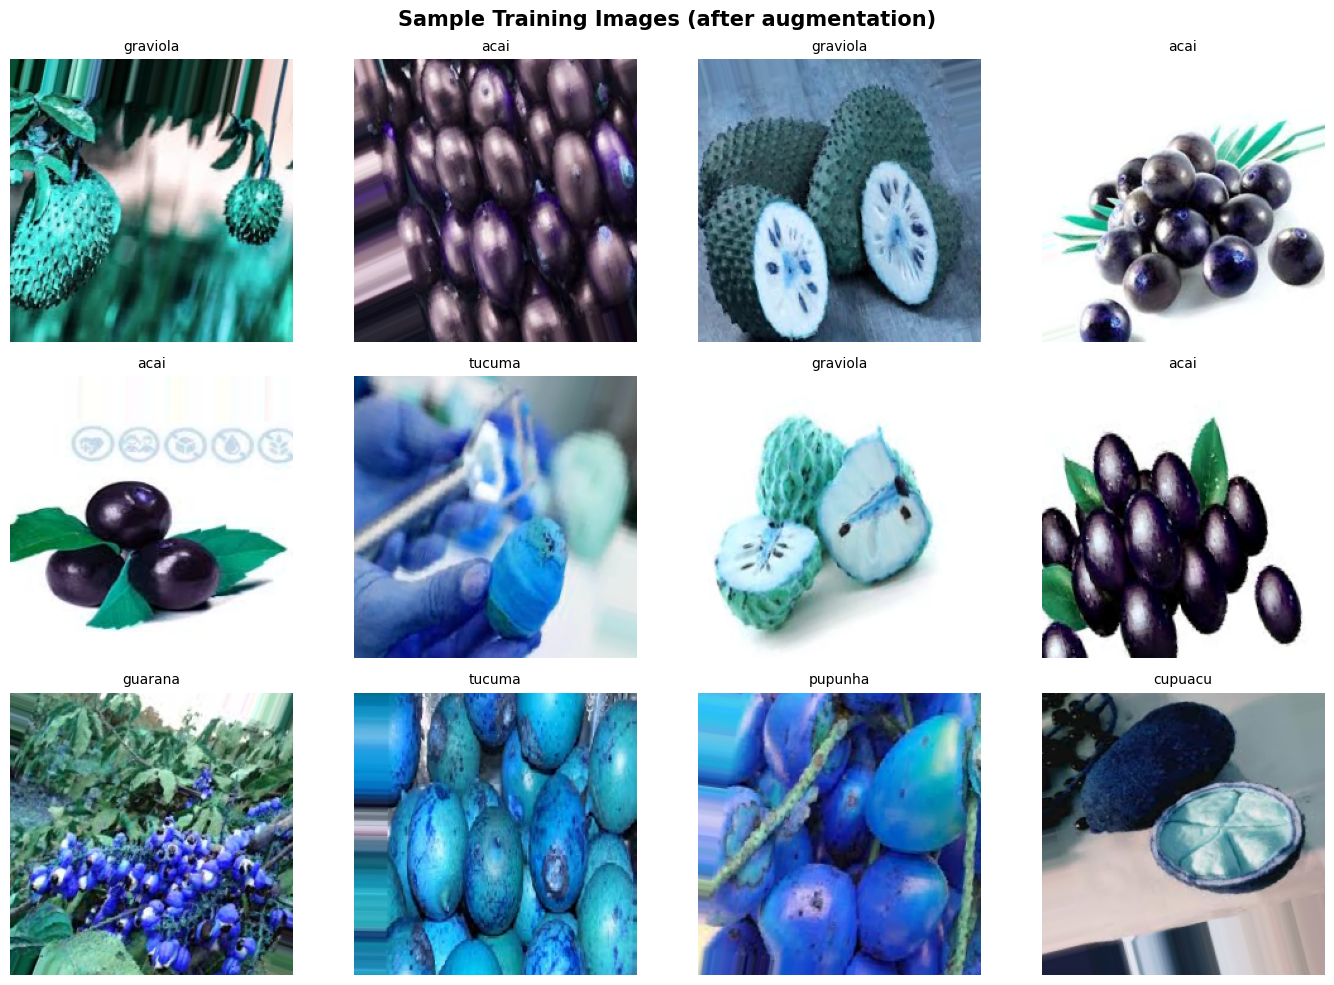

In [6]:
def show_sample_grid(generator, class_names, n=12):
    images, labels = next(generator)
    # Reverse VGG16 preprocessing for display
    disp = images.copy()
    disp += [103.939, 116.779, 123.68]   # add back ImageNet means
    disp  = np.clip(disp / 255.0, 0, 1)

    fig, axes = plt.subplots(3, 4, figsize=(14, 10))
    fig.suptitle('Sample Training Images (after augmentation)', fontsize=15, fontweight='bold')
    for i, ax in enumerate(axes.flat):
        if i >= n: break
        ax.imshow(disp[i])
        cls_idx = np.argmax(labels[i])
        ax.set_title(class_names[cls_idx], fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_sample_grid(train_gen, class_names)

---
## 🧊 5. Phase 1 — Feature Extraction
Load VGG16 with ImageNet weights, **freeze all convolutional layers**, add a custom classification head, and train with Adam.

In [7]:
#  Load VGG16 base (no top)
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(*IMG_SIZE, 3)
)

# Freeze ALL base layers
base_model.trainable = False

print(f"VGG16 base layers  : {len(base_model.layers)}")
print(f"Trainable params   : {base_model.count_params():,}   all frozen")

#  Custom classification head
inputs  = keras.Input(shape=(*IMG_SIZE, 3))
x       = base_model(inputs, training=False)   # BN layers stay in inference mode
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(512, activation='relu')(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.4)(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

feature_model = Model(inputs, outputs, name='VGG16_FeatureExtraction')

#  Compile with Adam
feature_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

feature_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
VGG16 base layers  : 19
Trainable params   : 14,714,688   all frozen


Model: "VGG16_FeatureExtraction"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,113,286 (57.65 MB)

 Trainable params: 397,062 (1.51 MB)

 Non-trainable params: 14,716,224 (56.14 MB)

In [8]:
EPOCHS_PHASE1 = 50

callbacks_phase1 = [
    EarlyStopping(monitor='val_accuracy', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_feature_model.h5',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

print('=' * 55)
print('  PHASE 1 — Feature Extraction Training')
print('=' * 55)

history_phase1 = feature_model.fit(
    train_gen,
    epochs=EPOCHS_PHASE1,
    validation_data=val_gen,
    callbacks=callbacks_phase1,
    verbose=1
)

# Evaluate on test set
loss_p1, acc_p1 = feature_model.evaluate(test_gen, verbose=0)
print(f"\n[Phase 1] Test Loss     : {loss_p1:.4f}")
print(f"[Phase 1] Test Accuracy : {acc_p1*100:.2f}%")

  PHASE 1 — Feature Extraction Training
Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.2136 - loss: 2.4740  
Epoch 1: val_accuracy improved from None to 0.33333, saving model to best_feature_model.h5



Epoch 1: finished saving model to best_feature_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 34s 10s/step - accuracy: 0.2308 - loss: 2.4671 - val_accuracy: 0.3333 - val_loss: 3.9508 - learning_rate: 0.0010
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 0.5543 - loss: 1.4595
Epoch 2: val_accuracy improved from 0.33333 to 0.58333, saving model to best_feature_model.h5



Epoch 2: finished saving model to best_feature_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 669ms/step - accuracy: 0.6410 - loss: 1.1416 - val_accuracy: 0.5833 - val_loss: 1.2503 - learning_rate: 0.0010
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - accuracy: 0.8678 - loss: 0.5461
Epoch 3: val_accuracy improved from 0.58333 to 0.83333, saving model to best_feature_model.h5



Epoch 3: finished saving model to best_feature_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 496ms/step - accuracy: 0.8590 - loss: 0.5184 - val_accuracy: 0.8333 - val_loss: 0.9580 - learning_rate: 0.0010
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.8879 - loss: 0.3315
Epoch 4: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 420ms/step - accuracy: 0.8974 - loss: 0.3248 - val_accuracy: 0.7500 - val_loss: 0.8741 - learning_rate: 0.0010
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.9331 - loss: 0.1916
Epoch 5: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 531ms/step - accuracy: 0.9359 - loss: 0.2305 - val_accuracy: 0.8333 - val_loss: 0.3208 - learning_rate: 0.0010
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step - accuracy: 0.9446 - loss: 0.2540
Epoch 6: val_accuracy improved from 0.83333 to 0.91667, saving model to best_feature_model.h5



Epoch 6: finished saving model to best_feature_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 742ms/step - accuracy: 0.9487 - loss: 0.1954 - val_accuracy: 0.9167 - val_loss: 0.1140 - learning_rate: 0.0010
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step - accuracy: 0.9770 - loss: 0.1438
Epoch 7: val_accuracy improved from 0.91667 to 1.00000, saving model to best_feature_model.h5



Epoch 7: finished saving model to best_feature_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 710ms/step - accuracy: 0.9744 - loss: 0.1332 - val_accuracy: 1.0000 - val_loss: 0.0571 - learning_rate: 0.0010
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step - accuracy: 0.9561 - loss: 0.1599
Epoch 8: val_accuracy did not improve from 1.00000
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 421ms/step - accuracy: 0.9744 - loss: 0.1115 - val_accuracy: 1.0000 - val_loss: 0.0528 - learning_rate: 0.0010
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - accuracy: 0.9519 - loss: 0.1103
Epoch 9: val_accuracy did not improve from 1.00000
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 425ms/step - accuracy: 0.9615 - loss: 0.0874 - val_accuracy: 1.0000 - val_loss: 0.0132 - learning_rate: 0.0010
Epoch 10/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 1.0000 - loss: 0.0537
Epoch 10: val_accuracy did not improve from 1.00000
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 407ms/step - accuracy: 1.0000 - loss: 0.0598 - val_accuracy: 1.0000 - val_loss: 0.0425 - le

---
##  6. Phase 2 — Fine-Tuning
Unfreeze the **last 2 layers (block5)** of VGG16 and retrain end-to-end with a much lower Adam learning rate.

In [9]:
#  Rebuild identical architecture
base_model_ft = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(*IMG_SIZE, 3)
)

# Freeze all EXCEPT the last convolutional block (block5)
FINE_TUNE_AT = len(base_model_ft.layers) - 2  # unfreeze last 2 layers
for layer in base_model_ft.layers[:FINE_TUNE_AT]:
    layer.trainable = False
for layer in base_model_ft.layers[FINE_TUNE_AT:]:
    layer.trainable = True

trainable_layers = [l.name for l in base_model_ft.layers if l.trainable]
print(f"Unfrozen VGG16 layers: {trainable_layers}")

# Same custom head
inputs  = keras.Input(shape=(*IMG_SIZE, 3))
x       = base_model_ft(inputs, training=True)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

finetune_model = Model(inputs, outputs, name='VGG16_FineTuning')

# Load best weights from Phase 1 into head layers
# (Transfer learned head weights by name matching)
for layer in finetune_model.layers:
    for feat_layer in feature_model.layers:
        if layer.name == feat_layer.name and layer.name != 'vgg16':
            try:
                layer.set_weights(feat_layer.get_weights())
            except:
                pass

# Compile with lower Adam LR
finetune_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),   # 100× lower
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

total_params     = finetune_model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in finetune_model.trainable_weights])
print(f"\nTotal params     : {total_params:,}")
print(f"Trainable params : {trainable_params:,}")
finetune_model.summary()

Unfrozen VGG16 layers: ['block5_conv3', 'block5_pool']

Total params     : 14,879,686
Trainable params : 2,524,806


Model: "VGG16_FineTuning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,879,686 (56.76 MB)

 Trainable params: 2,524,806 (9.63 MB)

 Non-trainable params: 12,354,880 (47.13 MB)

In [10]:
EPOCHS_PHASE2 = 100

callbacks_phase2 = [
    EarlyStopping(monitor='val_accuracy', patience=6,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-8, verbose=1),
    ModelCheckpoint('best_finetune_model.h5',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

print('=' * 55)
print('  PHASE 2 — Fine-Tuning Training')
print('=' * 55)

history_phase2 = finetune_model.fit(
    train_gen,
    epochs=EPOCHS_PHASE2,
    validation_data=val_gen,
    callbacks=callbacks_phase2,
    verbose=1
)

# Evaluate on test set
loss_p2, acc_p2 = finetune_model.evaluate(test_gen, verbose=0)
print(f"\n[Phase 2] Test Loss     : {loss_p2:.4f}")
print(f"[Phase 2] Test Accuracy : {acc_p2*100:.2f}%")
print(f"\n📈 Improvement from Phase 1 → Phase 2: +{(acc_p2 - acc_p1)*100:.2f}%")

  PHASE 2 — Fine-Tuning Training
Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2246 - loss: 4.8239
Epoch 1: val_accuracy improved from None to 0.50000, saving model to best_finetune_model.h5



Epoch 1: finished saving model to best_finetune_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.1923 - loss: 4.6839 - val_accuracy: 0.5000 - val_loss: 2.3406 - learning_rate: 1.0000e-04
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 0.4702 - loss: 1.6783
Epoch 2: val_accuracy improved from 0.50000 to 0.58333, saving model to best_finetune_model.h5



Epoch 2: finished saving model to best_finetune_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 556ms/step - accuracy: 0.5385 - loss: 1.5343 - val_accuracy: 0.5833 - val_loss: 1.0162 - learning_rate: 1.0000e-04
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 0.8418 - loss: 0.5440
Epoch 3: val_accuracy improved from 0.58333 to 0.75000, saving model to best_finetune_model.h5



Epoch 3: finished saving model to best_finetune_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 661ms/step - accuracy: 0.8205 - loss: 0.6416 - val_accuracy: 0.7500 - val_loss: 1.0697 - learning_rate: 1.0000e-04
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - accuracy: 0.8550 - loss: 0.3906
Epoch 4: val_accuracy did not improve from 0.75000
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 406ms/step - accuracy: 0.8462 - loss: 0.4138 - val_accuracy: 0.5833 - val_loss: 0.5934 - learning_rate: 1.0000e-04
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 700ms/step - accuracy: 0.9519 - loss: 0.1394
Epoch 5: val_accuracy improved from 0.75000 to 0.83333, saving model to best_finetune_model.h5



Epoch 5: finished saving model to best_finetune_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.9487 - loss: 0.1621 - val_accuracy: 0.8333 - val_loss: 0.8223 - learning_rate: 1.0000e-04
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - accuracy: 0.9872 - loss: 0.0757
Epoch 6: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 487ms/step - accuracy: 0.9615 - loss: 0.1223 - val_accuracy: 0.8333 - val_loss: 0.7754 - learning_rate: 1.0000e-04
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - accuracy: 0.9412 - loss: 0.1399
Epoch 7: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 7: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 400ms/step - accuracy: 0.9487 - loss: 0.1375 - val_accuracy: 0.8333 - val_loss: 0.8707 - learning_rate: 1.0000e-04
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step - accuracy: 0.9872 - loss: 0.0293
Epoch 8: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 564


Epoch 10: finished saving model to best_finetune_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 543ms/step - accuracy: 1.0000 - loss: 0.0172 - val_accuracy: 0.9167 - val_loss: 0.3770 - learning_rate: 5.0000e-05
Epoch 11/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 1.0000 - loss: 0.0234
Epoch 11: val_accuracy did not improve from 0.91667
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 405ms/step - accuracy: 1.0000 - loss: 0.0220 - val_accuracy: 0.9167 - val_loss: 0.4439 - learning_rate: 5.0000e-05
Epoch 12/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 1.0000 - loss: 0.0290
Epoch 12: val_accuracy did not improve from 0.91667
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 391ms/step - accuracy: 1.0000 - loss: 0.0275 - val_accuracy: 0.9167 - val_loss: 0.3642 - learning_rate: 5.0000e-05
Epoch 13/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step - accuracy: 1.0000 - loss: 0.0374
Epoch 13: val_accuracy did not improve from 0.91667
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 643ms/step - accuracy: 1.0000 - loss: 0.0307 - val_accuracy: 0.8333 - 

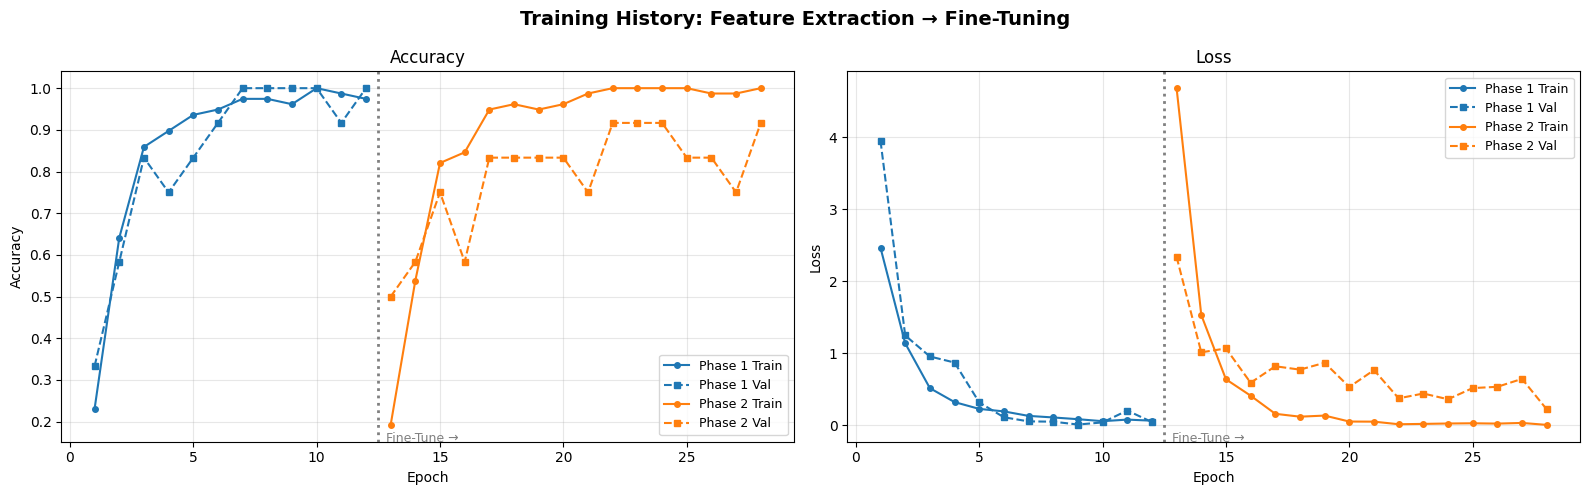

In [11]:
def plot_combined_history(h1, h2, metric='accuracy'):
    """
    Plot Phase 1 and Phase 2 training curves side-by-side
    with a clear boundary and improvement annotation.
    """
    ep1 = range(1, len(h1.history[metric]) + 1)
    ep2 = range(len(ep1) + 1, len(ep1) + len(h2.history[metric]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle('Training History: Feature Extraction → Fine-Tuning',
                 fontsize=14, fontweight='bold')

    for ax, met, title in zip(
        axes,
        ['accuracy', 'loss'],
        ['Accuracy', 'Loss']
    ):
        val_met = 'val_' + met

        # Phase 1
        ax.plot(ep1, h1.history[met],     'C0-o', ms=4, label='Phase 1 Train')
        ax.plot(ep1, h1.history[val_met], 'C0--s', ms=4, label='Phase 1 Val')

        # Phase 2
        ax.plot(ep2, h2.history[met],     'C1-o', ms=4, label='Phase 2 Train')
        ax.plot(ep2, h2.history[val_met], 'C1--s', ms=4, label='Phase 2 Val')

        # Boundary
        boundary = len(ep1) + 0.5
        ax.axvline(x=boundary, color='gray', linestyle=':', linewidth=2)
        ax.text(boundary + 0.3, ax.get_ylim()[0], 'Fine-Tune →',
                color='gray', fontsize=9)

        ax.set_xlabel('Epoch')
        ax.set_ylabel(title)
        ax.set_title(title)
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_combined_history(history_phase1, history_phase2)

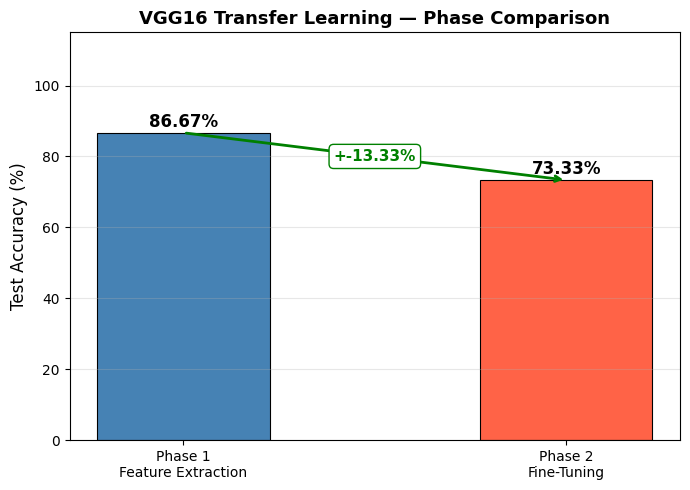

In [12]:
# ── Bar chart comparing Phase 1 vs Phase 2 ──────────────────
phases  = ['Phase 1\nFeature Extraction', 'Phase 2\nFine-Tuning']
acc_vals = [acc_p1 * 100, acc_p2 * 100]
colors   = ['steelblue', 'tomato']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(phases, acc_vals, color=colors, width=0.45, edgecolor='black', linewidth=0.8)

for bar, val in zip(bars, acc_vals):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{val:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

# Improvement arrow
ax.annotate('',
            xy=(1, acc_p2 * 100), xytext=(0, acc_p1 * 100),
            arrowprops=dict(arrowstyle='->', color='green', lw=2))
mid_y = (acc_p1 + acc_p2) / 2 * 100
ax.text(0.5, mid_y, f'+{(acc_p2-acc_p1)*100:.2f}%',
        ha='center', va='center', color='green',
        fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='green'))

ax.set_ylim(0, 115)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('VGG16 Transfer Learning — Phase Comparison', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 🔍 8. Detailed Evaluation — Classification Report & Confusion Matrix

In [13]:
test_gen.reset()
y_pred_prob = finetune_model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = test_gen.classes

print('\n' + '='*55)
print('  Classification Report — Fine-Tuned VGG16')
print('='*55)
print(classification_report(
    y_true, y_pred,
    target_names=class_names,
    digits=4
))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

  Classification Report — Fine-Tuned VGG16
              precision    recall  f1-score   support

        acai     1.0000    0.4000    0.5714         5
     cupuacu     0.6667    0.8000    0.7273         5
    graviola     1.0000    0.6000    0.7500         5
     guarana     0.7500    0.6000    0.6667         5
     pupunha     0.7143    1.0000    0.8333         5
      tucuma     0.6250    1.0000    0.7692         5

    accuracy                         0.7333        30
   macro avg     0.7927    0.7333    0.7197        30
weighted avg     0.7927    0.7333    0.7197        30



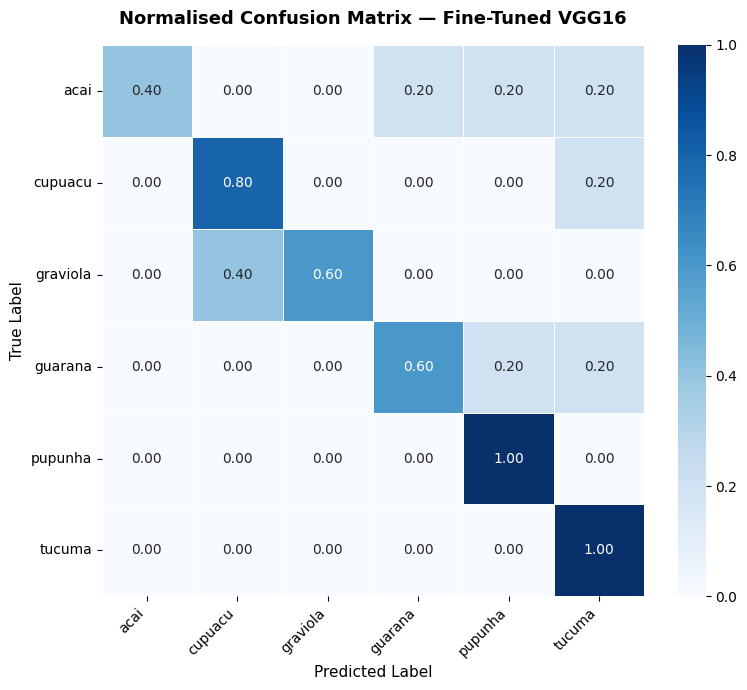

In [14]:
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(max(8, NUM_CLASSES), max(7, NUM_CLASSES - 1)))
sns.heatmap(
    cm_norm,
    annot=True, fmt='.2f',
    xticklabels=class_names,
    yticklabels=class_names,
    cmap='Blues',
    linewidths=0.5,
    ax=ax
)
ax.set_title('Normalised Confusion Matrix — Fine-Tuned VGG16',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label',      fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 📈 9. Per-Class Accuracy Bar Chart

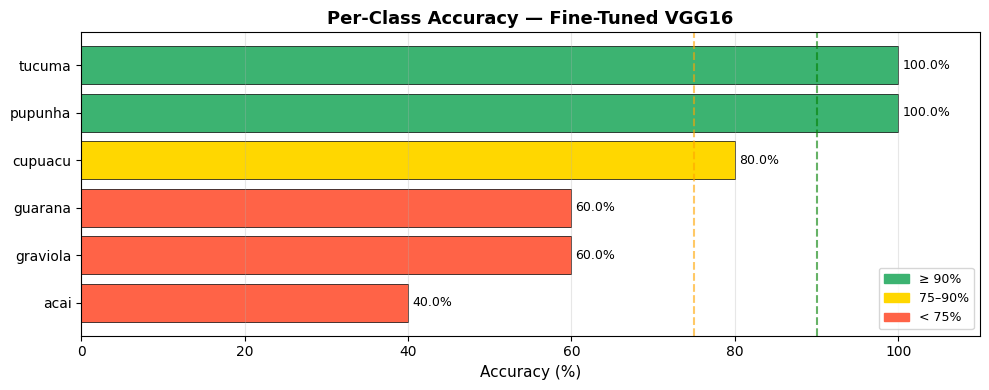

In [15]:
per_class_acc = cm_norm.diagonal()

sorted_idx = np.argsort(per_class_acc)
sorted_classes = [class_names[i] for i in sorted_idx]
sorted_acc     = per_class_acc[sorted_idx]

fig, ax = plt.subplots(figsize=(10, max(4, NUM_CLASSES * 0.45)))
colors_bar = ['tomato' if a < 0.75 else 'gold' if a < 0.90 else 'mediumseagreen'
              for a in sorted_acc]
ax.barh(sorted_classes, sorted_acc * 100, color=colors_bar, edgecolor='black', linewidth=0.5)

for i, (cls, val) in enumerate(zip(sorted_classes, sorted_acc)):
    ax.text(val * 100 + 0.5, i, f'{val*100:.1f}%', va='center', fontsize=9)

ax.axvline(x=90, color='green',  linestyle='--', alpha=0.6, label='90% threshold')
ax.axvline(x=75, color='orange', linestyle='--', alpha=0.6, label='75% threshold')

handles = [
    mpatches.Patch(color='mediumseagreen', label='≥ 90%'),
    mpatches.Patch(color='gold',           label='75–90%'),
    mpatches.Patch(color='tomato',         label='< 75%'),
]
ax.legend(handles=handles, loc='lower right', fontsize=9)

ax.set_xlabel('Accuracy (%)', fontsize=11)
ax.set_title('Per-Class Accuracy — Fine-Tuned VGG16', fontsize=13, fontweight='bold')
ax.set_xlim(0, 110)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()